# Local LLM Benchmark Analysis
**Hardware:** MacBook Air M4, 32GB RAM, fanless, 120 GB/s bandwidth  
**Engine:** LM Studio (llama.cpp GGUF backend)  
**Models:** 3 MoE finalists from 10+ candidates  
**Date:** April 10-11, 2026  

### Models
| Model | Size | Quant | Active Params | Thinking |
|-------|------|-------|---------------|----------|
| **Qwen3-Coder-30B-A3B** | 17GB | Q4_K_M | 3B | No |
| **Gemma 4 26B-A4B** | 16GB | Q4_K_M | 4B | Yes (heavy) |
| **huihui-ref** (Qwen3.5-35B-A3B abliterated) | 14GB | Q3_K_S | 3B | Yes (moderate) |

### Known Issues
- **MATH scores are affected by a bug:** `max_tokens=4096` was hardcoded instead of 16384. Thinking models got truncated (25 questions for Gemma, 32 for huihui). Scores shown are lower bounds.
- **Gemma 4 GPQA was not tested** at 100q due to high token usage per question (3000-16000 thinking tokens). Data from ~16 trial questions shows it CAN answer them correctly.
- All other benchmarks (MMLU, HumanEval, DROP, GPQA for Qwen3-Coder and huihui) are valid.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

with open('extracted/master_summary.json') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['duration_min'] = df['duration_s'] / 60
df['score_pct_num'] = df['score'] * 100
df['avg_time_per_q'] = df['duration_s'] / df['total']
df['efficiency'] = df['score_pct_num'] / df['duration_min']  # % per minute

# Color scheme
COLORS = {'Qwen3-Coder': '#2196F3', 'Gemma4': '#FF5722', 'huihui-ref': '#4CAF50'}
BENCH_ORDER = ['mmlu', 'humaneval', 'math', 'drop', 'gpqa']
BENCH_LABELS = {'mmlu': 'MMLU\n(Knowledge)', 'humaneval': 'HumanEval\n(Code)', 
                'math': 'MATH\n(Reasoning)', 'drop': 'DROP\n(Comprehension)', 
                'gpqa': 'GPQA\n(Graduate)'}
MODEL_ORDER = ['Qwen3-Coder', 'Gemma4', 'huihui-ref']

print(f"Loaded {len(df)} benchmark results")
df[['model', 'benchmark', 'score_pct', 'duration_min', 'truncated_at_max_tokens', 'bugged_max_tokens']]

Loaded 15 benchmark results


,model,benchmark,score_pct,duration_min,truncated_at_max_tokens,bugged_max_tokens
0,Qwen3-Coder,mmlu,67%,8.800000,0,False
1,Qwen3-Coder,humaneval,94%,14.900000,0,False
2,Qwen3-Coder,gpqa,42%,38.416667,0,False
3,Qwen3-Coder,drop,80%,10.983333,0,False
4,Gemma4,mmlu,84%,73.200000,0,False
5,Gemma4,humaneval,99%,185.250000,0,False
6,Gemma4,drop,89%,96.500000,0,False
7,huihui-ref,mmlu,78%,69.700000,1,False
8,huihui-ref,humaneval,91%,84.033333,1,False
9,huihui-ref,drop,89%,26.783333,0,False


## 1. Score vs Time — The Core Tradeoff
Each subplot is one benchmark. X-axis = time (minutes), Y-axis = score (%). The ideal model is in the **top-left** corner (high score, low time).

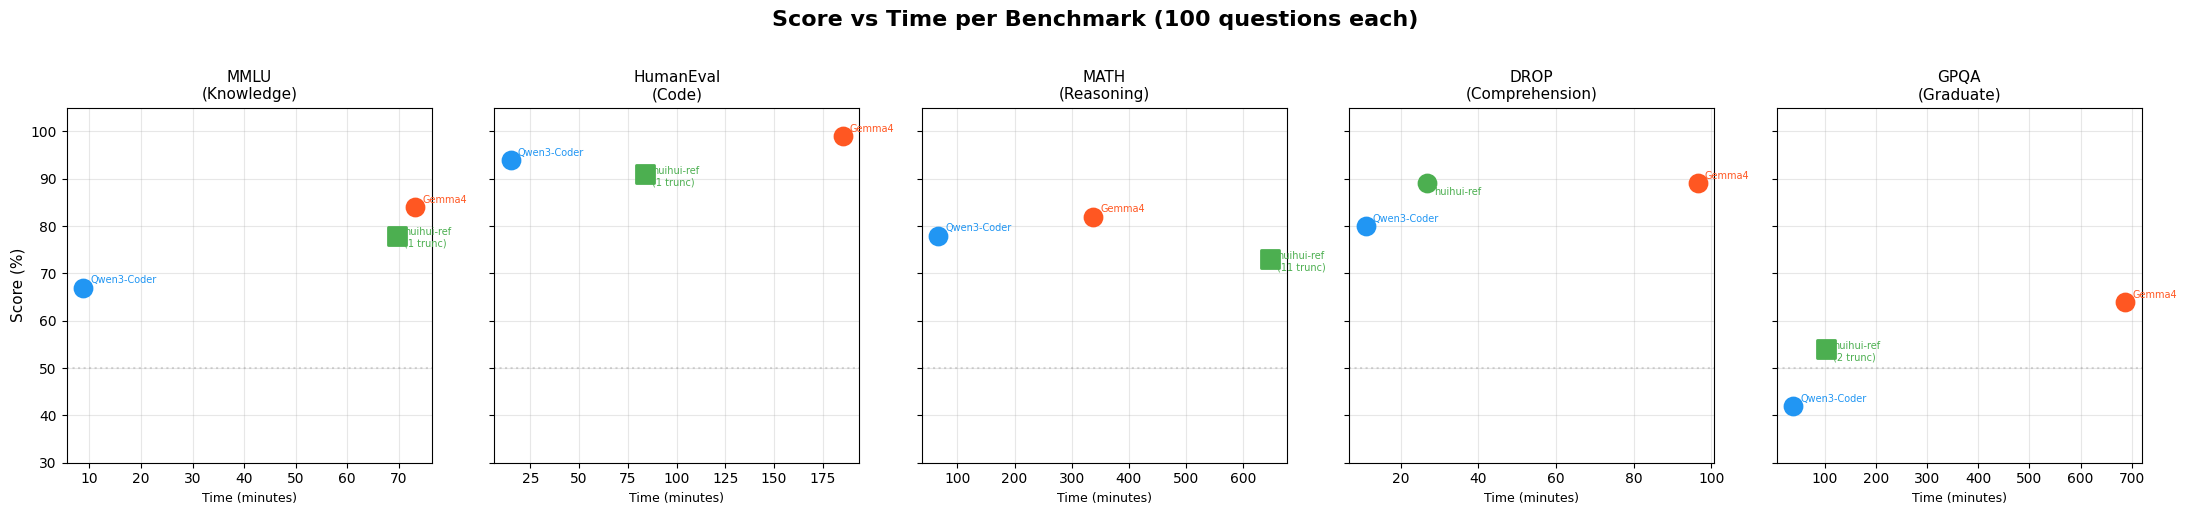

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
fig.suptitle('Score vs Time per Benchmark (100 questions each)', fontsize=16, fontweight='bold', y=1.02)

for idx, bench in enumerate(BENCH_ORDER):
    ax = axes[idx]
    bench_data = df[df['benchmark'] == bench]
    
    for _, row in bench_data.iterrows():
        color = COLORS[row['model']]
        # Mark entries with any remaining truncations (e.g., huihui MATH at 32k)
        has_trunc = row['truncated_at_max_tokens'] > 0
        marker = 's' if has_trunc else 'o'
        size = 180 if has_trunc else 150
        
        ax.scatter(row['duration_min'], row['score_pct_num'], 
                   c=color, s=size, marker=marker, edgecolors=color, linewidths=2, zorder=5)
        
        offset_y = 3 if row['model'] != 'huihui-ref' else -8
        label = row['model']
        if has_trunc:
            label += f"\n({int(row['truncated_at_max_tokens'])} trunc)"
        ax.annotate(label, (row['duration_min'], row['score_pct_num']),
                    textcoords='offset points', xytext=(5, offset_y), fontsize=7, color=color)
    
    ax.set_title(BENCH_LABELS.get(bench, bench), fontsize=11)
    ax.set_xlabel('Time (minutes)', fontsize=9)
    if idx == 0:
        ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_ylim(30, 105)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=50, color='gray', linestyle=':', alpha=0.3, label='50%')
    
    missing = set(MODEL_ORDER) - set(bench_data['model'])
    if missing:
        ax.text(0.5, 0.15, f"{', '.join(missing)}:\nnot tested", 
                transform=ax.transAxes, ha='center', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('chart_score_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Efficiency: Score per Minute
How much quality do you get per minute of waiting? Higher = better.

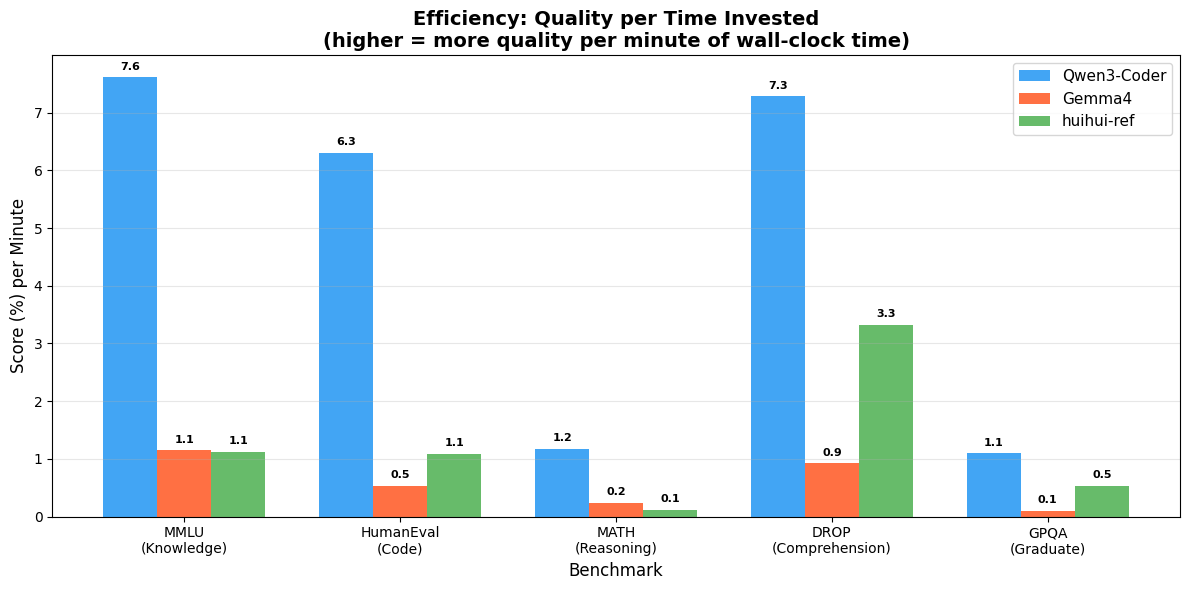

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

benches_present = [b for b in BENCH_ORDER]
x = np.arange(len(benches_present))
width = 0.25

for i, model in enumerate(MODEL_ORDER):
    model_data = df[df['model'] == model]
    vals = []
    for b in benches_present:
        row = model_data[model_data['benchmark'] == b]
        if len(row) > 0:
            vals.append(row.iloc[0]['efficiency'])
        else:
            vals.append(0)
    
    bars = ax.bar(x + i * width, vals, width, label=model, color=COLORS[model], alpha=0.85)
    
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('Score (%) per Minute', fontsize=12)
ax.set_title('Efficiency: Quality per Time Invested\n(higher = more quality per minute of wall-clock time)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([BENCH_LABELS.get(b, b) for b in benches_present])
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Raw Scores Comparison

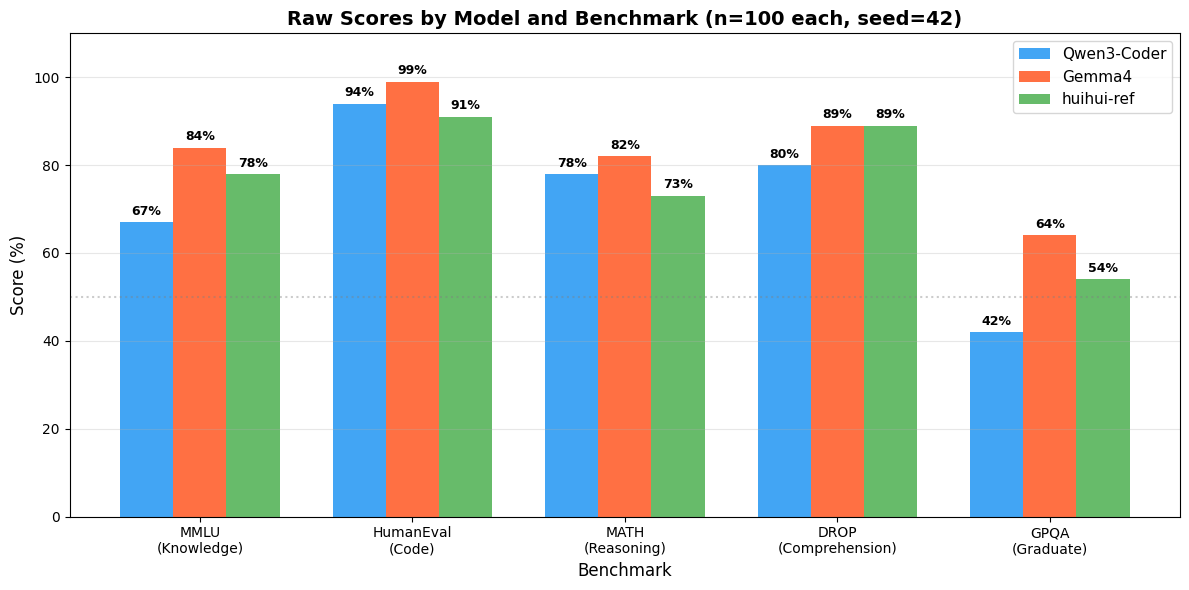

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(benches_present))
width = 0.25

for i, model in enumerate(MODEL_ORDER):
    model_data = df[df['model'] == model]
    scores = []
    for b in benches_present:
        row = model_data[model_data['benchmark'] == b]
        if len(row) > 0:
            scores.append(row.iloc[0]['score_pct_num'])
        else:
            scores.append(0)
    
    bars = ax.bar(x + i * width, scores, width, label=model, color=COLORS[model], alpha=0.85)
    for bar, score in zip(bars, scores):
        if score > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{score:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Raw Scores by Model and Benchmark (n=100 each, seed=42)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([BENCH_LABELS.get(b, b) for b in benches_present])
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.4)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_raw_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Time Breakdown: Where Does Each Model Spend Its Time?

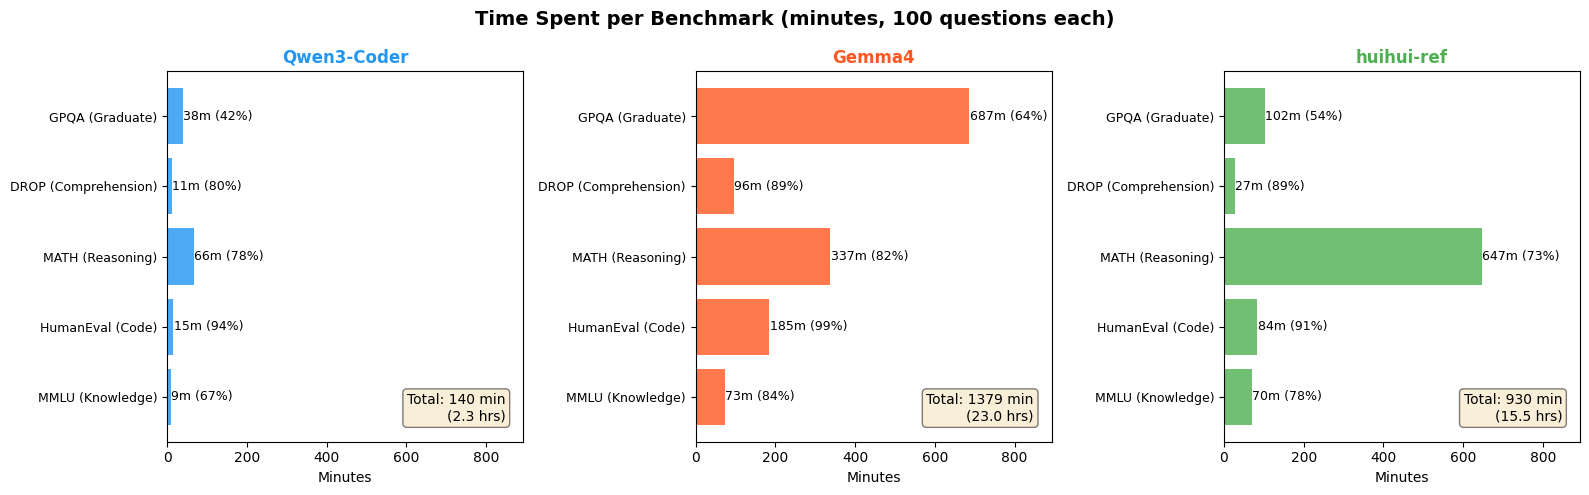

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Time Spent per Benchmark (minutes, 100 questions each)', fontsize=14, fontweight='bold')

for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    model_data = df[df['model'] == model].copy()
    model_data = model_data.set_index('benchmark').reindex([b for b in BENCH_ORDER if b in model_data['benchmark'].values])
    
    benches = model_data.index.tolist()
    times = model_data['duration_min'].values
    scores = model_data['score_pct_num'].values
    
    bars = ax.barh(range(len(benches)), times, color=COLORS[model], alpha=0.8)
    
    for j, (bar, t, s) in enumerate(zip(bars, times, scores)):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{t:.0f}m ({s:.0f}%)', va='center', fontsize=9)
    
    ax.set_yticks(range(len(benches)))
    ax.set_yticklabels([BENCH_LABELS.get(b, b).replace('\n', ' ') for b in benches], fontsize=9)
    ax.set_xlabel('Minutes', fontsize=10)
    ax.set_title(model, fontsize=12, fontweight='bold', color=COLORS[model])
    ax.set_xlim(0, max(df['duration_min']) * 1.3)
    
    total = model_data['duration_s'].sum() / 60
    ax.text(0.95, 0.05, f'Total: {total:.0f} min\n({total/60:.1f} hrs)', 
            transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('chart_time_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Token Economy: Thinking vs Visible Output

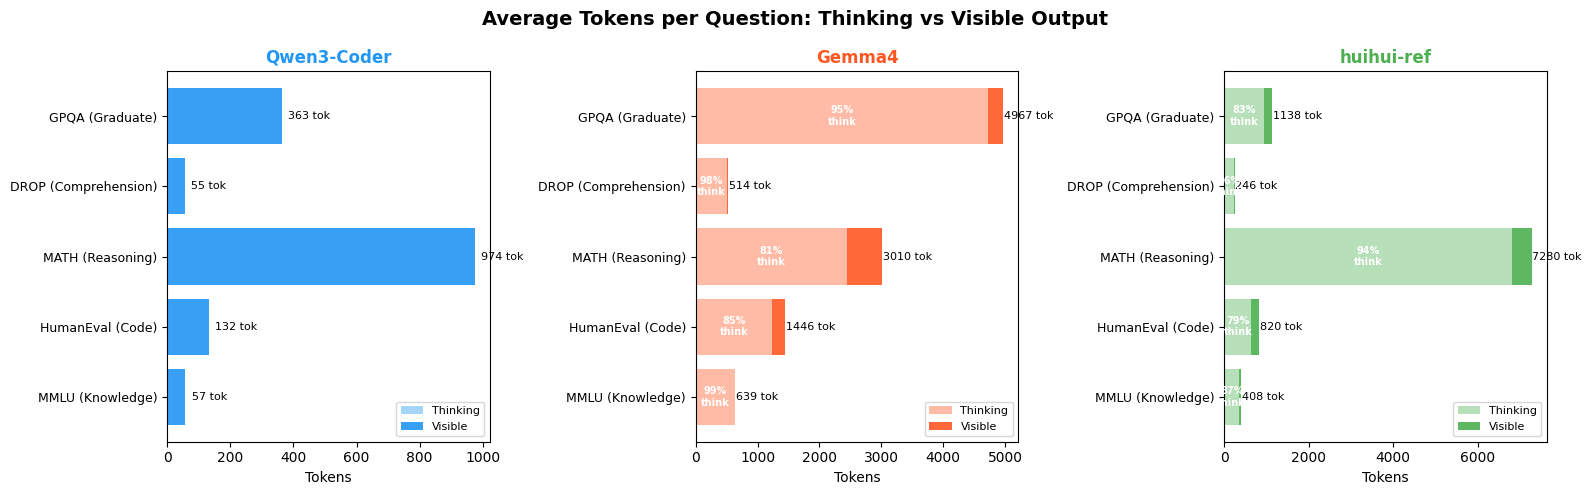

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Average Tokens per Question: Thinking vs Visible Output', fontsize=14, fontweight='bold')

for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    model_data = df[df['model'] == model]
    
    benches = [b for b in BENCH_ORDER if b in model_data['benchmark'].values]
    think = [model_data[model_data['benchmark']==b].iloc[0]['avg_reasoning_tokens'] for b in benches]
    visible = [model_data[model_data['benchmark']==b].iloc[0]['avg_visible_tokens'] for b in benches]
    
    y = range(len(benches))
    ax.barh(y, think, color=COLORS[model], alpha=0.4, label='Thinking')
    ax.barh(y, visible, left=think, color=COLORS[model], alpha=0.9, label='Visible')
    
    for j in range(len(benches)):
        total = think[j] + visible[j]
        if total > 0:
            pct_think = think[j] / total * 100 if total > 0 else 0
            ax.text(total + 20, j, f'{total:.0f} tok', va='center', fontsize=8)
            if think[j] > 0:
                ax.text(think[j]/2, j, f'{pct_think:.0f}%\nthink', va='center', ha='center', 
                       fontsize=7, color='white', fontweight='bold')
    
    ax.set_yticks(y)
    ax.set_yticklabels([BENCH_LABELS.get(b, b).replace('\n', ' ') for b in benches], fontsize=9)
    ax.set_xlabel('Tokens', fontsize=10)
    ax.set_title(model, fontsize=12, fontweight='bold', color=COLORS[model])
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('chart_token_economy.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. MATH Truncation: Before vs After the Fix

The original runs hit `max_tokens=4096` (hardcoded bug) causing thinking models to run out of budget mid-reasoning. All MATH runs were redone with `max_tokens=32768` and the fixed `\boxed{}` regex. This chart shows the **current state** after the fix — how many questions still hit the token limit at 32,768.

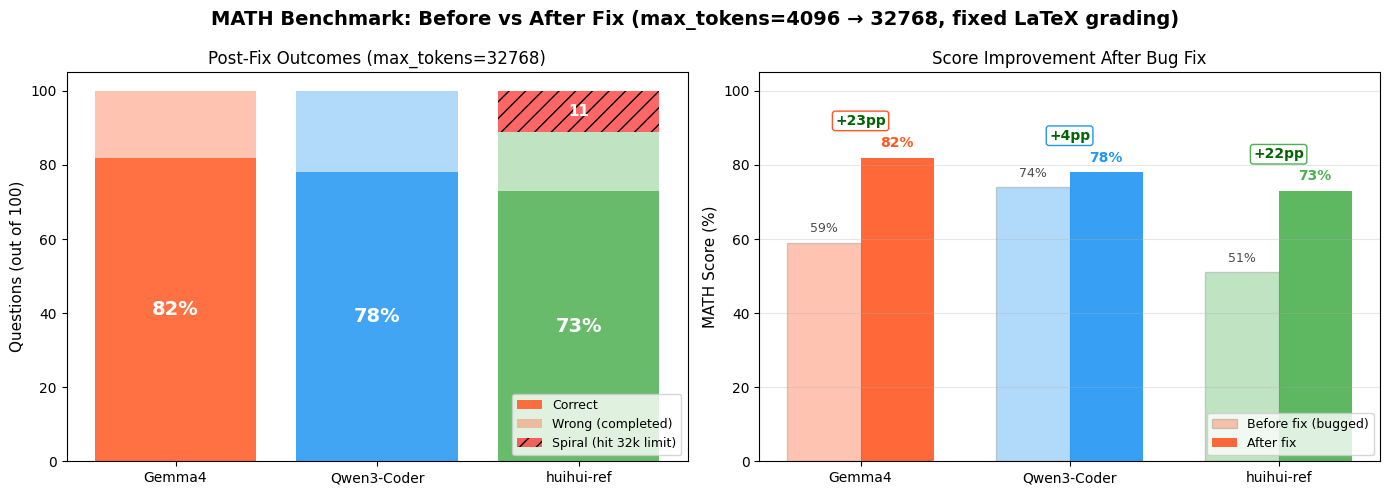

In [7]:
math_data = df[df['benchmark'] == 'math'].copy().sort_values('model').reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MATH Benchmark: Before vs After Fix (max_tokens=4096 → 32768, fixed LaTeX grading)', fontsize=14, fontweight='bold')

# Left: stacked bar showing correct / wrong / truncated AFTER fix
models = math_data['model'].tolist()
correct = math_data['correct'].tolist()
truncated = math_data['truncated_at_max_tokens'].tolist()
wrong_not_trunc = [100 - c - t for c, t in zip(correct, truncated)]

x = range(len(models))
colors_model = [COLORS[m] for m in models]

ax1.bar(x, correct, color=colors_model, alpha=0.85, label='Correct')
ax1.bar(x, wrong_not_trunc, bottom=correct, color=colors_model, alpha=0.35, label='Wrong (completed)')
ax1.bar(x, truncated, bottom=[c+w for c,w in zip(correct, wrong_not_trunc)], 
        color='red', alpha=0.6, label='Spiral (hit 32k limit)', hatch='//')

for j in range(len(models)):
    ax1.text(j, correct[j]/2, f'{correct[j]}%', ha='center', va='center', fontweight='bold', fontsize=14, color='white')
    if truncated[j] > 0:
        ax1.text(j, correct[j] + wrong_not_trunc[j] + truncated[j]/2, 
                f'{truncated[j]}', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

ax1.set_xticks(list(x))
ax1.set_xticklabels(models, fontsize=10)
ax1.set_ylabel('Questions (out of 100)', fontsize=11)
ax1.set_title('Post-Fix Outcomes (max_tokens=32768)', fontsize=12)
ax1.legend(fontsize=9, loc='lower right')
ax1.set_ylim(0, 105)

# Right: grouped bars (before / after) per model, clearly separated
before_scores = {'Gemma4': 59, 'huihui-ref': 51, 'Qwen3-Coder': 74}
after_scores = {row['model']: row['correct'] for _, row in math_data.iterrows()}

x2 = list(range(len(models)))
width = 0.35
before_vals = [before_scores[m] for m in models]
after_vals = [after_scores[m] for m in models]

bars_before = ax2.bar([p - width/2 for p in x2], before_vals, width,
                       color=[COLORS[m] for m in models], alpha=0.35,
                       label='Before fix (bugged)', edgecolor='gray')
bars_after = ax2.bar([p + width/2 for p in x2], after_vals, width,
                      color=[COLORS[m] for m in models], alpha=0.9,
                      label='After fix')

for j, model in enumerate(models):
    before = before_scores[model]
    after = after_scores[model]
    delta = after - before
    ax2.text(j - width/2, before + 2, f'{before}%', ha='center', va='bottom', fontsize=9, alpha=0.7)
    ax2.text(j + width/2, after + 2, f'{after}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color=COLORS[model])
    ax2.text(j, max(before, after) + 8, f'{delta:+d}pp', ha='center', va='bottom', fontsize=10,
             fontweight='bold', color='darkgreen' if delta > 0 else 'darkred',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=COLORS[model]))

ax2.set_xticks(x2)
ax2.set_xticklabels(models, fontsize=10)
ax2.set_ylabel('MATH Score (%)', fontsize=11)
ax2.set_title('Score Improvement After Bug Fix', fontsize=12)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart_math_bug_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-Question Completion Tokens Distribution

How much does each model generate per question? Uses combined timing data (new MATH + old logs for other benchmarks). For MATH, shows the real post-fix distribution without the 4096 truncation artifact.

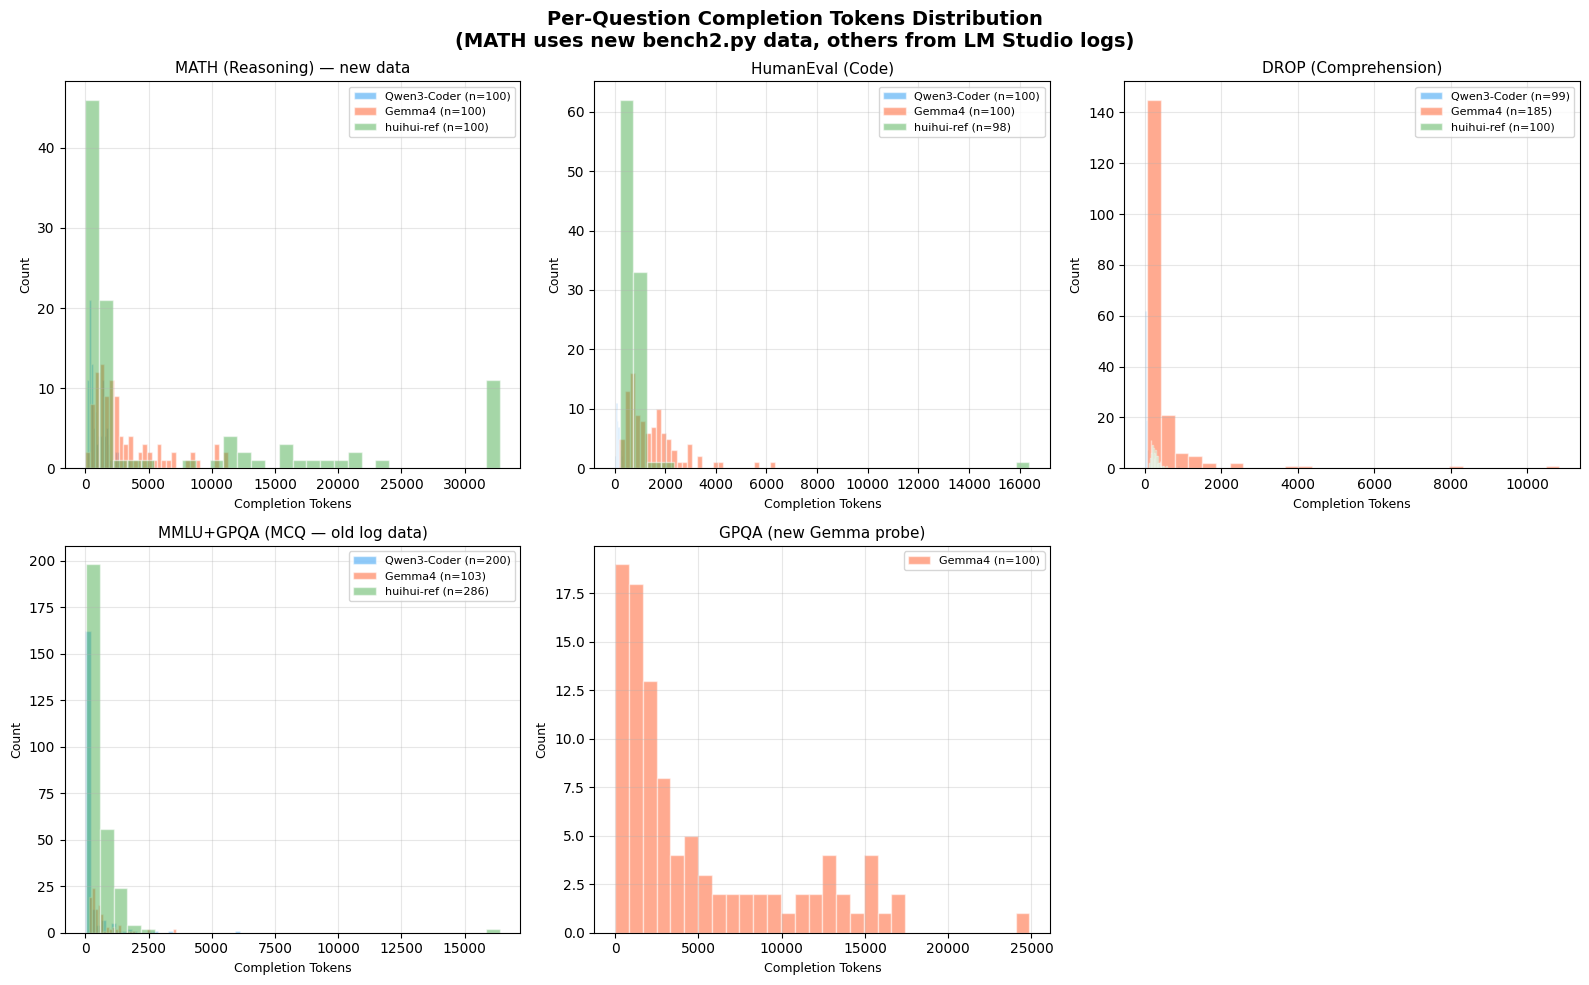

In [8]:
# Load combined per-question data (new MATH + old LM Studio logs for other benchmarks)
pq = []
with open('extracted/per_question_timing_combined.jsonl') as f:
    for line in f:
        pq.append(json.loads(line))
pq_df = pd.DataFrame(pq)

# Drop old 'model' column (the full model_id), keep model_short
if 'model' in pq_df.columns:
    pq_df = pq_df.drop(columns=['model'])

# Filter to 3 target models
pq_df = pq_df[pq_df['model_short'].isin(MODEL_ORDER)].copy()
pq_df = pq_df.rename(columns={'model_short': 'model', 'bench': 'benchmark', 'comp': 'completion_tokens'})

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Per-Question Completion Tokens Distribution\n(MATH uses new bench2.py data, others from LM Studio logs)', fontsize=14, fontweight='bold')

# Show: math (new), humaneval, drop, mcq (MMLU+GPQA old), gpqa (new Gemma probe)
plot_benches = [
    ('math', 'MATH (Reasoning) — new data'),
    ('humaneval', 'HumanEval (Code)'),
    ('drop', 'DROP (Comprehension)'),
    ('mcq', 'MMLU+GPQA (MCQ — old log data)'),
    ('gpqa', 'GPQA (new Gemma probe)'),
]

for idx, (bench, label) in enumerate(plot_benches):
    ax = axes[idx // 3][idx % 3]
    
    for model in MODEL_ORDER:
        subset = pq_df[(pq_df['model'] == model) & (pq_df['benchmark'] == bench)]
        if len(subset) == 0:
            continue
        tokens = subset['completion_tokens'].values
        ax.hist(tokens, bins=30, alpha=0.5, color=COLORS[model], label=f'{model} (n={len(tokens)})', edgecolor='white')
    
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Completion Tokens', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('chart_token_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Table

In [9]:
summary = df[['model', 'benchmark', 'score_pct', 'duration_min', 'avg_completion_tokens', 
              'avg_reasoning_tokens', 'avg_visible_tokens', 'truncated_at_max_tokens',
              'tok_per_second']].copy()
summary.columns = ['Model', 'Benchmark', 'Score', 'Time (min)', 'Avg Completion Tok',
                    'Avg Thinking Tok', 'Avg Visible Tok', 'Truncated', 'tok/s']
summary = summary.sort_values(['Model', 'Benchmark'])

# Highlight any rows with truncations remaining
def highlight_truncated(row):
    if row['Truncated'] > 0:
        return ['background-color: #fff3cd'] * len(row)
    return [''] * len(row)

summary.style.apply(highlight_truncated, axis=1)

,Model,Benchmark,Score,Time (min),Avg Completion Tok,Avg Thinking Tok,Avg Visible Tok,Truncated,tok/s
6,Gemma4,drop,89%,96.500000,514,506,8,0,16.000000
14,Gemma4,gpqa,64.0%,687.000000,4966,4729,238,0,12.000000
5,Gemma4,humaneval,99%,185.250000,1446,1233,213,0,13.000000
11,Gemma4,math,82.0%,337.483333,3011,2441,569,0,14.900000
4,Gemma4,mmlu,84%,73.200000,639,634,5,0,14.500000
3,Qwen3-Coder,drop,80%,10.983333,55,0,55,0,8.200000
2,Qwen3-Coder,gpqa,42%,38.416667,363,0,363,0,15.700000
1,Qwen3-Coder,humaneval,94%,14.900000,132,0,132,0,14.800000
13,Qwen3-Coder,math,78.0%,66.416667,974,0,974,0,24.500000
0,Qwen3-Coder,mmlu,67%,8.800000,57,0,57,0,10.800000


## 9. Analysis: What Model is Best for What?

Based on the corrected data (MATH reruns with max_tokens=32768 + fixed LaTeX grading, plus Gemma GPQA full 100q run). All scores are from 100-question samples with seed=42.

### The numbers

| | Qwen3-Coder | Gemma 4 | huihui-ref |
|---|---:|---:|---:|
| MMLU | 67% | **84%** | 78% |
| HumanEval | 94% | **99%** | 91% |
| MATH | 78% | **82%** | 73% |
| DROP | 80% | **89%** | **89%** |
| GPQA | 42% | **64%** | 54% |
| **Avg** | **72.2%** | **83.6%** | **77.0%** |
| **Total time** | **2.3h** | 24.0h | 15.5h |

### What the data proves

**Gemma 4 wins on quality.** Best on all 5 benchmarks (tied with huihui on DROP). Average is 11.4 pp higher than Qwen3-Coder and 6.6 pp higher than huihui-ref. This contradicts the previous report which claimed Gemma was worst at MATH — that was an artifact of two bugs (max_tokens cap + broken regex). After the fix, Gemma is best on math reasoning too.

**Gemma 4's GPQA score (64%) is striking.** For context: GPT-4 scores ~40%, Claude 3.5 Sonnet ~60%, Claude 4 Opus ~85%. A 16GB local MoE model is scoring between GPT-4 and Claude 3.5 Sonnet on a PhD-level science benchmark. That's not what we expected going in.

**Qwen3-Coder wins on speed by 10x.** All 5 benchmarks in 139 minutes vs Gemma's 1,440 minutes (24 hours). Zero thinking tokens per question — every token goes to the visible answer. The speed is consistent and never hit max_tokens limits because it never burns thinking tokens.

**huihui-ref sits between but doesn't win at anything.** Slower than Qwen3-Coder, lower-scoring than Gemma 4 on every benchmark except DROP (tied). On hard MATH problems, 11 out of 100 questions hit the 32,768-token limit — genuine thinking spirals that 32k tokens couldn't resolve.

### The time/quality tradeoff

Gemma 4 scores 11.4 pp higher than Qwen3-Coder on average but takes **10.4x longer** (1440 min vs 139 min). That's **12.2 min per percentage point** of quality for Gemma 4 vs **1.9 min/pp** for Qwen3-Coder — Qwen3-Coder is **6.4x more efficient** per unit of quality gained.

Whether that tradeoff is worth it depends entirely on use case:
- **Speed-critical interactive use**: Qwen3-Coder only. Gemma's 5-15 min latency per question is too much.
- **Batch jobs or high volume**: Qwen3-Coder wins. Its speed compounds over many queries.
- **Research / hard questions**: Gemma 4. The +17 pp on MMLU and +22 pp on GPQA matter, and the thinking is legitimate reasoning (verified by inspecting the raw thinking tokens).
- **One-off hard questions you'd send to Claude/GPT anyway**: Gemma 4 at a fraction of the cost. 64% GPQA matches Claude 3.5 Sonnet.

### Caveats

- **Gemma 4 GPQA (64%)** had 7 per-question timeouts (30-min limit hit with 0 tokens returned). These counted as failures. Without timeouts or with a longer timeout, score could be slightly higher.
- **huihui-ref MATH (73%)** has 11 spiraling questions that didn't finish even at 32,768 tokens. Its true ceiling might be slightly higher with 64k+ tokens.
- **Times are wall-clock on a fanless MacBook Air M4**. Different hardware would shift absolute numbers but likely preserve relative ratios.
- **Swap usage grew to 8-11GB during long Gemma runs** — some memory pressure, but no observed speed degradation or errors.
- **All scores are n=100 samples** with ±~5pp confidence intervals. Small differences (1-3pp) between models should be treated as noise.

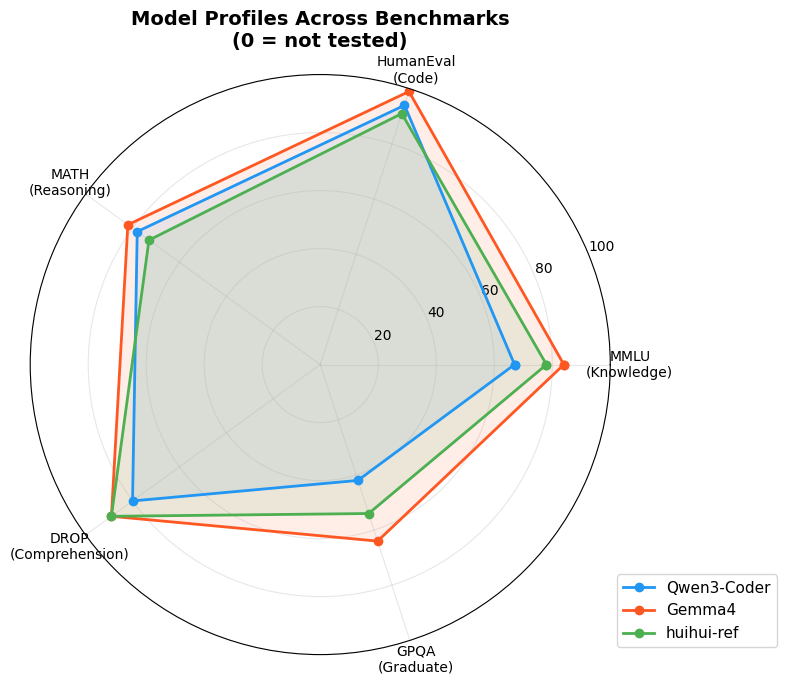

In [10]:
# Radar chart: each model's profile across benchmarks
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Only use benchmarks where all models have data, plus show gaps
radar_benches = ['mmlu', 'humaneval', 'math', 'drop', 'gpqa']
angles = np.linspace(0, 2 * np.pi, len(radar_benches), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

for model in MODEL_ORDER:
    model_data = df[df['model'] == model]
    values = []
    for b in radar_benches:
        row = model_data[model_data['benchmark'] == b]
        values.append(row.iloc[0]['score_pct_num'] if len(row) > 0 else 0)
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=COLORS[model], markersize=6)
    ax.fill(angles, values, alpha=0.1, color=COLORS[model])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([BENCH_LABELS.get(b, b).replace('\n', '\n') for b in radar_benches], fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('Model Profiles Across Benchmarks\n(0 = not tested)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chart_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Speed Analysis: What Affects Inference Speed?

Combined dataset: **2,021 per-question entries** covering all 5 benchmarks.

- **MATH (300 entries)**: from the new bench2.py reruns with `max_tokens=32768`, correctly graded
- **Everything else (1,711 entries)**: from LM Studio server log extraction — token counts and timings are valid even though the original runs had bugged MATH grading

What we want to know:
- **Speed vs position in run** (does it slow down = possible thermal throttling?)
- **Speed vs output length** (does generating more tokens change tok/s?)
- **Speed vs prompt size**
- **Which model is actually fastest and how consistent is it**

## 11. Open Questions & Status

### Completed ✓
1. ✓ **MATH reruns with max_tokens=32768** — Gemma 82%, huihui 73%, Qwen3-Coder 78%. Bug fix confirmed: Gemma gained +23pp, huihui +22pp, Qwen +4pp.
2. ✓ **Context length impact on speed** — tested 1k through 64k. No meaningful slowdown from larger context; RAM grows modestly.
3. ✓ **Gemma 4 GPQA full 100q** — **64%** (strongest overall). Took 11.4 hours. 7 questions hit the 30-min per-question timeout.

### Still open
4. **huihui-ref MATH spirals** — 11 questions hit the 32,768 limit. Would need 64k+ to know if the model can answer them. (Low priority — huihui is not leading on MATH anyway.)
5. **Gemma 4 reasoning=off mode** — Gemma 4's LM Studio capabilities show `reasoning: {allowed_options: [off, on]}`. Untested. Could potentially run Gemma at Qwen3-Coder-like speed without thinking. Worth investigating.
6. **Vision-capable models**: Gemma 4 and HauhauCS have `vision: true`. We haven't tested any vision benchmarks. Could add VQA or image-based questions if useful.
7. **MMLU-Pro & HLE**: logical next-step benchmarks. MMLU-Pro for better differentiation at the top of the scale (10 choices vs 4). HLE probably too hard for these model sizes but worth a 50q probe.
8. **Thermal behavior under sustained load** — longest observed run was 11.4h (Gemma GPQA). MacBook Air is fanless, no throttling observed at ~70°C sustained.

In [11]:
# Load combined per-question timing data (new MATH + old LM Studio logs)
timing = []
with open('extracted/per_question_timing_combined.jsonl') as f:
    for line in f:
        timing.append(json.loads(line))
tdf = pd.DataFrame(timing)

# Drop old 'model' (full id), use model_short
if 'model' in tdf.columns:
    tdf = tdf.drop(columns=['model'])

# Filter to 3 target models
tdf = tdf[tdf['model_short'].isin(['Qwen3-Coder', 'Gemma4', 'huihui-ref'])].copy()
# Filter out rows with missing/bad speed data
tdf = tdf[tdf['actual_tok_s'].notna() & (tdf['actual_tok_s'] > 0)].copy()

# Parse request time to datetime for time-series plots
tdf['req_dt'] = pd.to_datetime(tdf['req_time'], errors='coerce')
tdf = tdf.sort_values('req_dt').reset_index(drop=True)

print(f'Total valid entries: {len(tdf)}')
print(f'By model/benchmark:')
print(tdf.groupby(['model_short', 'bench']).size().to_string())

Total valid entries: 2074
By model/benchmark:
model_short  bench    
Gemma4       drop         185
             gpqa          93
             humaneval    100
             math          98
             mcq          103
             unknown      136
Qwen3-Coder  drop          99
             humaneval    100
             math         100
             mcq          200
             unknown      185
huihui-ref   drop         100
             humaneval     98
             math          99
             mcq          286
             unknown       92


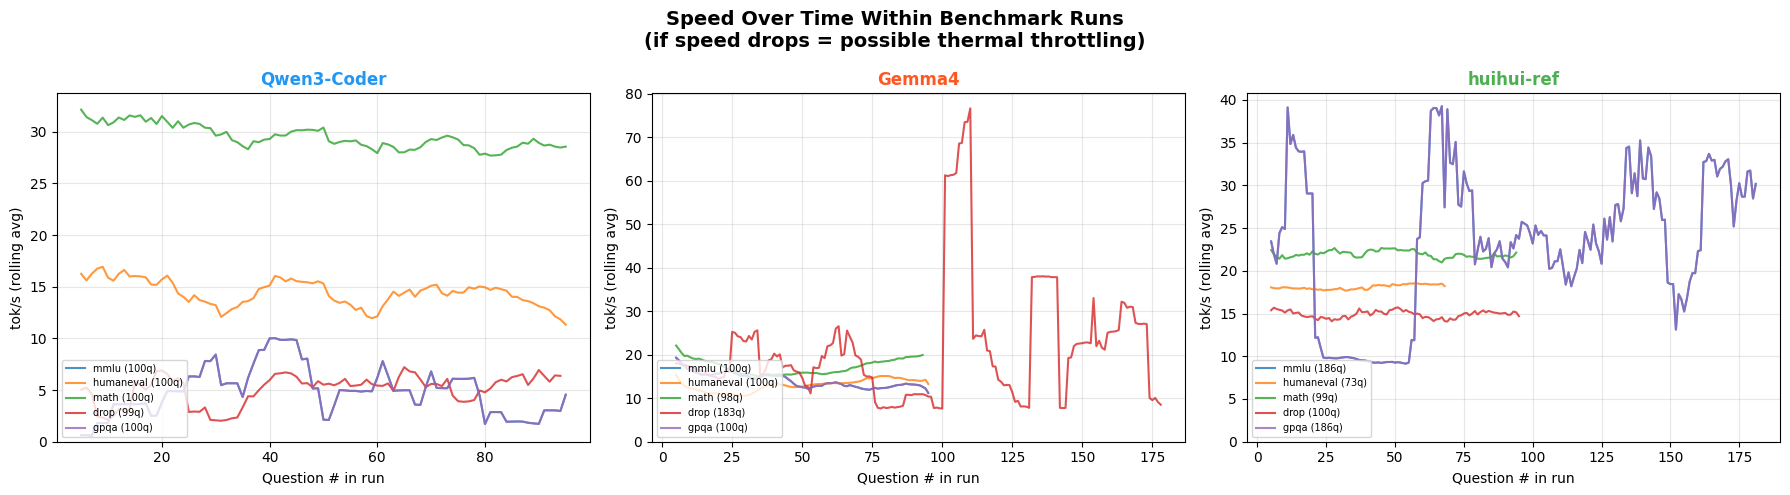

In [12]:
### 10a. Speed over time within a run — thermal throttling?
# For each model's longest continuous run, plot tok/s over question number
# If the MacBook Air throttles, speed should drop as the run progresses

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Speed Over Time Within Benchmark Runs\n(if speed drops = possible thermal throttling)', 
             fontsize=14, fontweight='bold')

for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    model_data = tdf[tdf['model_short'] == model].sort_values('req_dt')
    
    for bench in BENCH_ORDER:
        bench_data = model_data[model_data['bench'] == ('mcq' if bench in ('mmlu','gpqa') else bench)]
        if len(bench_data) < 20:
            continue
        
        # Find the longest continuous run (gap < 10 min)
        bench_data = bench_data.copy()
        bench_data['gap'] = bench_data['req_dt'].diff().dt.total_seconds().fillna(0)
        bench_data['run_break'] = (bench_data['gap'] > 600).cumsum()
        biggest_run = bench_data.groupby('run_break').size().idxmax()
        run_data = bench_data[bench_data['run_break'] == biggest_run].copy()
        
        if len(run_data) < 20:
            continue
        
        run_data['q_num'] = range(len(run_data))
        
        # Rolling average for smoothness
        window = min(10, len(run_data) // 5)
        if window >= 2:
            smoothed = run_data['actual_tok_s'].rolling(window, center=True).mean()
            ax.plot(run_data['q_num'], smoothed, label=f'{bench} ({len(run_data)}q)', alpha=0.8, linewidth=1.5)
        else:
            ax.plot(run_data['q_num'], run_data['actual_tok_s'], label=f'{bench} ({len(run_data)}q)', alpha=0.6)
    
    ax.set_xlabel('Question # in run', fontsize=10)
    ax.set_ylabel('tok/s (rolling avg)', fontsize=10)
    ax.set_title(model, fontsize=12, fontweight='bold', color=COLORS[model])
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig('chart_speed_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

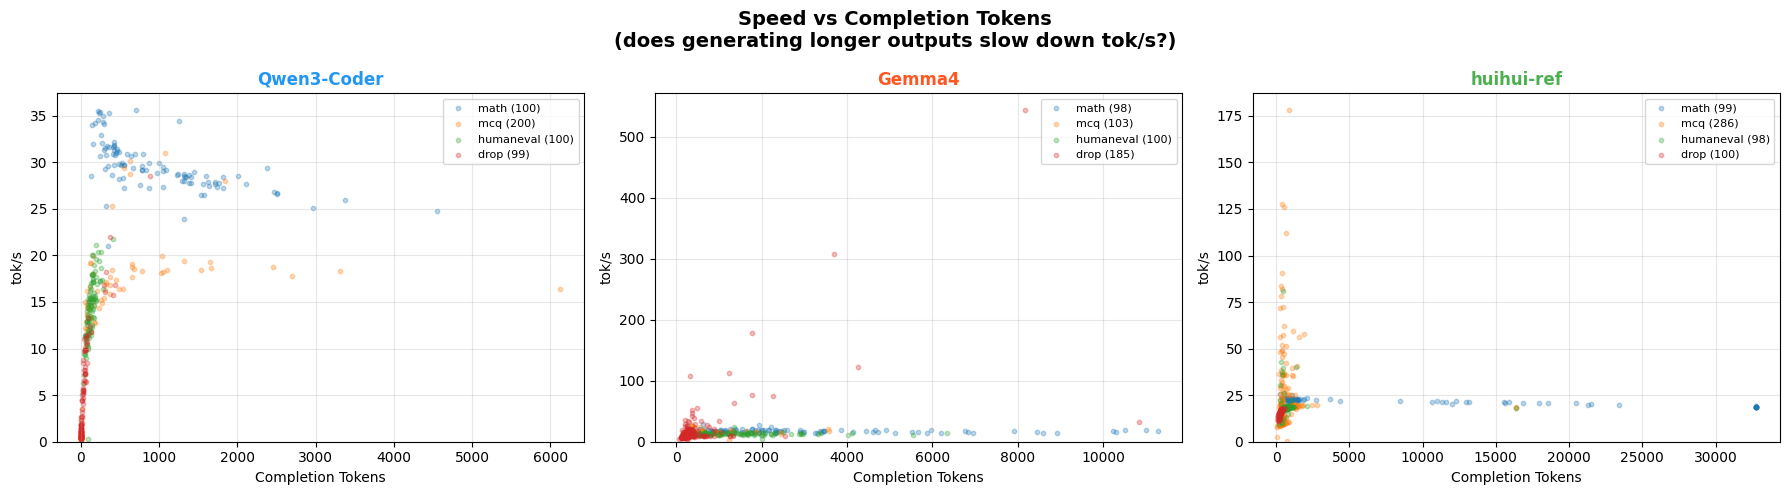

In [13]:
### 10b. Speed vs Output Length — does generating more tokens change tok/s?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Speed vs Completion Tokens\n(does generating longer outputs slow down tok/s?)', 
             fontsize=14, fontweight='bold')

for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    model_data = tdf[tdf['model_short'] == model]
    
    for bench in ['math', 'mcq', 'humaneval', 'drop']:
        sub = model_data[model_data['bench'] == bench]
        if len(sub) < 10:
            continue
        ax.scatter(sub['comp'], sub['actual_tok_s'], alpha=0.3, s=10, 
                   label=f'{bench} ({len(sub)})', color=None)
    
    ax.set_xlabel('Completion Tokens', fontsize=10)
    ax.set_ylabel('tok/s', fontsize=10)
    ax.set_title(model, fontsize=12, fontweight='bold', color=COLORS[model])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig('chart_speed_vs_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

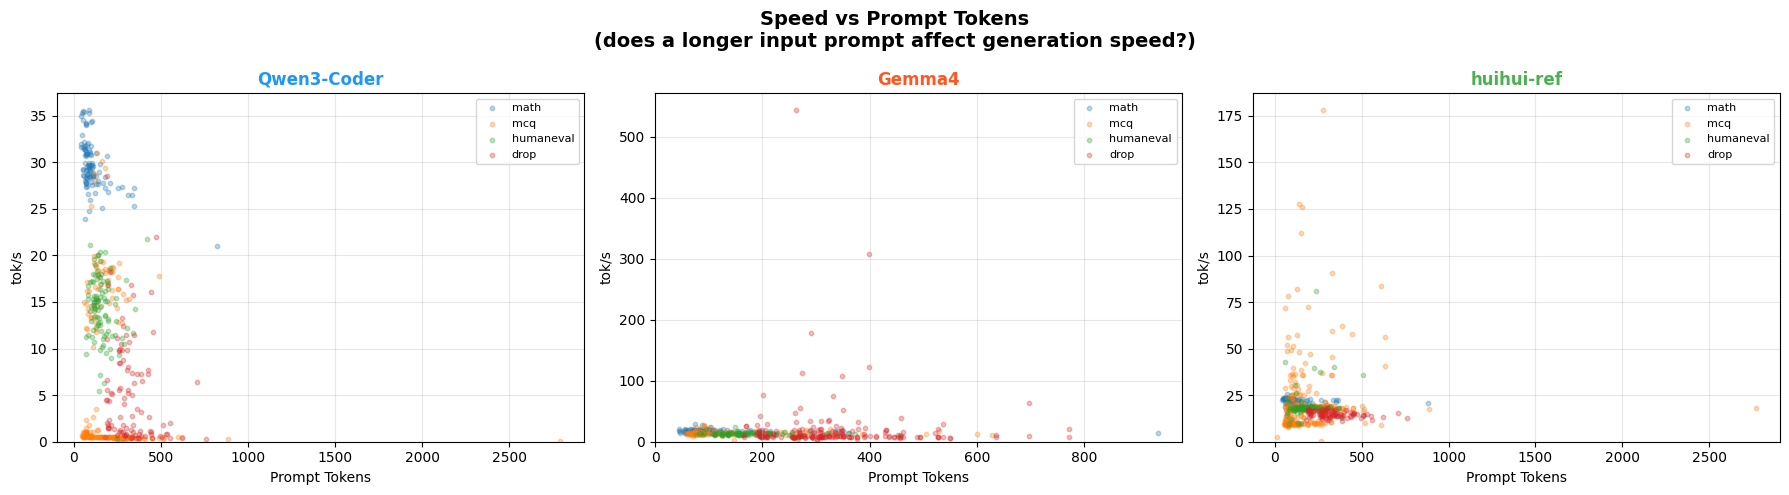

In [14]:
### 10c. Speed vs Prompt Size — does a bigger prompt slow things down?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Speed vs Prompt Tokens\n(does a longer input prompt affect generation speed?)', 
             fontsize=14, fontweight='bold')

for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    model_data = tdf[tdf['model_short'] == model]
    
    for bench in ['math', 'mcq', 'humaneval', 'drop']:
        sub = model_data[model_data['bench'] == bench]
        if len(sub) < 10:
            continue
        ax.scatter(sub['prompt'], sub['actual_tok_s'], alpha=0.3, s=10, label=f'{bench}')
    
    ax.set_xlabel('Prompt Tokens', fontsize=10)
    ax.set_ylabel('tok/s', fontsize=10)
    ax.set_title(model, fontsize=12, fontweight='bold', color=COLORS[model])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig('chart_speed_vs_prompt.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/lc/7vtyynln67z25sk9qbxfhv0r0000gn/T/ipykernel_27921/340317555.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6,


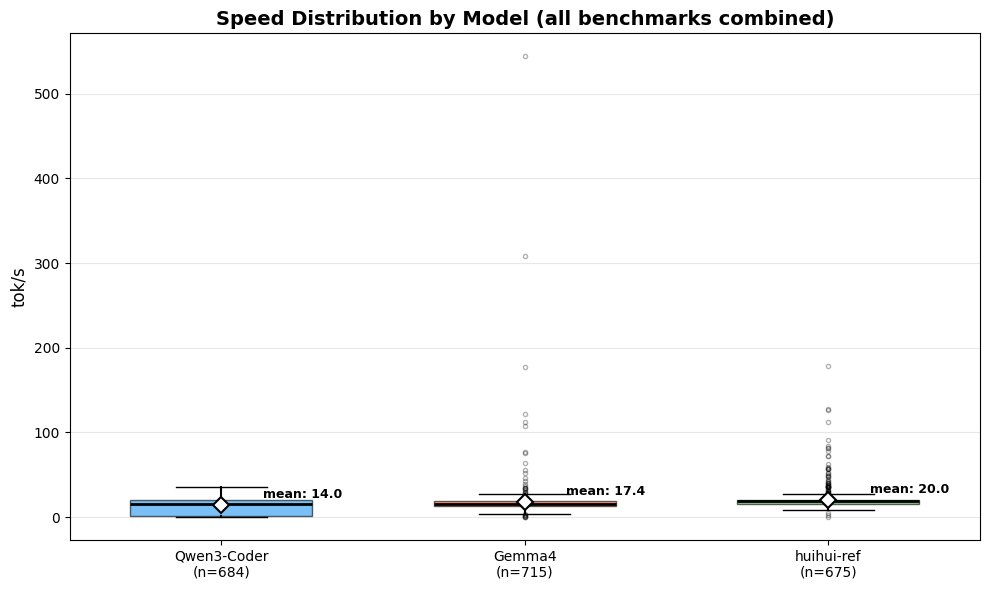

In [15]:
### 10d. Speed comparison across models (box plots)
fig, ax = plt.subplots(figsize=(10, 6))

box_data = []
box_labels = []
box_colors = []
for model in MODEL_ORDER:
    sub = tdf[tdf['model_short'] == model]['actual_tok_s']
    box_data.append(sub.values)
    box_labels.append(f"{model}\n(n={len(sub)})")
    box_colors.append(COLORS[model])

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                flierprops=dict(markersize=3, alpha=0.3))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('tok/s', fontsize=12)
ax.set_title('Speed Distribution by Model (all benchmarks combined)', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Add mean markers
for i, data in enumerate(box_data):
    mean_val = np.mean(data)
    ax.plot(i + 1, mean_val, 'D', color='white', markersize=8, markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    ax.annotate(f'mean: {mean_val:.1f}', (i + 1, mean_val), textcoords='offset points', 
                xytext=(30, 5), fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_speed_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/lc/7vtyynln67z25sk9qbxfhv0r0000gn/T/ipykernel_27921/562570629.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


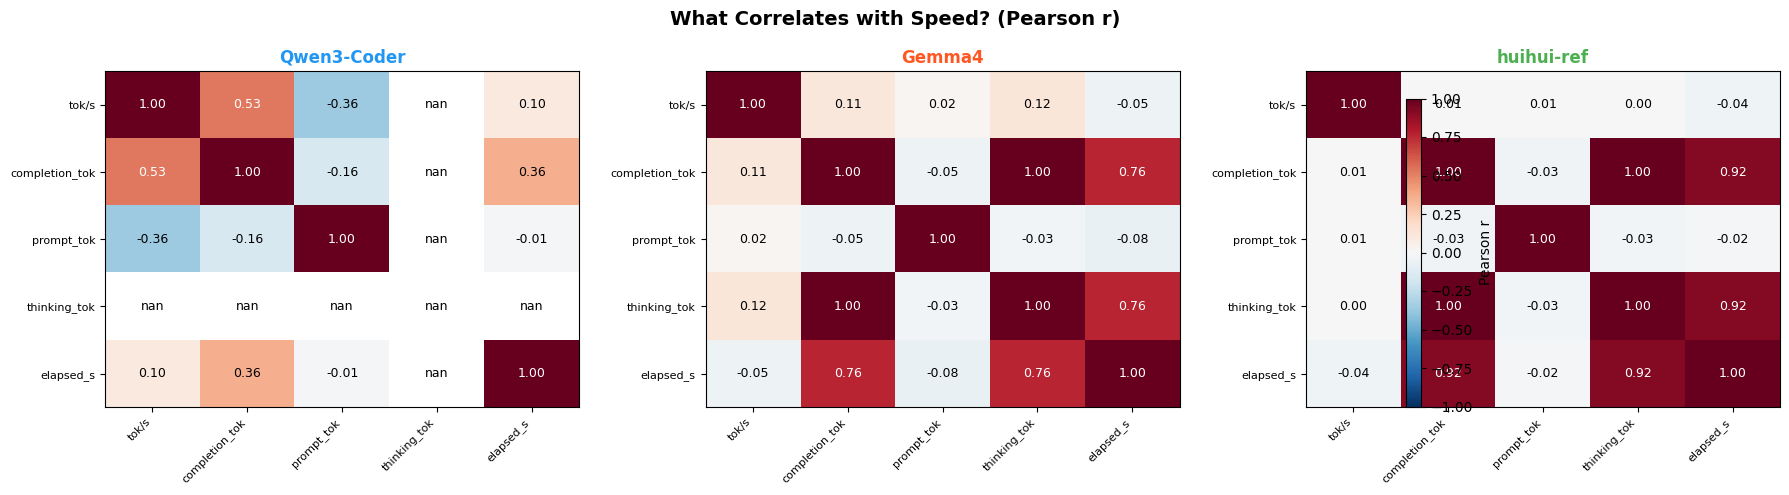

In [16]:
### 10e. Correlation matrix — what correlates with speed?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('What Correlates with Speed? (Pearson r)', fontsize=14, fontweight='bold')

for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    sub = tdf[tdf['model_short'] == model][['actual_tok_s', 'comp', 'prompt', 'think', 'elapsed_s']].copy()
    sub.columns = ['tok/s', 'completion_tok', 'prompt_tok', 'thinking_tok', 'elapsed_s']
    
    corr = sub.corr()
    
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(corr.columns, fontsize=8)
    
    for y_idx in range(len(corr)):
        for x_idx in range(len(corr)):
            val = corr.iloc[y_idx, x_idx]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(x_idx, y_idx, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)
    
    ax.set_title(model, fontsize=12, fontweight='bold', color=COLORS[model])

plt.colorbar(im, ax=axes, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.savefig('chart_speed_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Context Length vs Speed

Does allocating a larger KV cache (`context_length` in LM Studio) slow down inference?

Tested **Gemma 4 26B-A4B** at 7 context sizes (1024 → 65536), same 3 questions each time (MMLU, DROP, MATH), temp=0, with warmup after each reload.

In [17]:
# Load context-length benchmark data
with open('extracted/context_speed_bench.json') as f:
    ctx_data = json.load(f)

ctx_df = pd.DataFrame(ctx_data)

# Extract tok/s columns
for q in ['MMLU (short)', 'DROP (medium)', 'MATH (thinking)']:
    ctx_df[f'{q}_tok_s'] = ctx_df[f'{q}_tok_s'].astype(float)
    ctx_df[f'{q}_comp_tok'] = ctx_df[f'{q}_comp_tok'].astype(int)

print(ctx_df[['context_length', 'ram_mb', 'swap_mb', 
              'MMLU (short)_tok_s', 'DROP (medium)_tok_s', 'MATH (thinking)_tok_s',
              'MATH (thinking)_comp_tok']].to_string(index=False))

 context_length  ram_mb  swap_mb  MMLU (short)_tok_s  DROP (medium)_tok_s  MATH (thinking)_tok_s  MATH (thinking)_comp_tok
           1024   18424     2252                26.3                 25.4                   27.9                       956
           2048   18747     2244                28.0                 26.6                   23.4                      1980
           4096   18166     2171                22.4                 23.3                   18.2                      3911
           8192   19181     2890                24.9                 21.6                   20.7                      3911
          16384   19511     3305                19.9                 21.8                   18.8                      3911
          32768   19844     3105                24.3                 23.7                   19.2                      3911
          65536   19367     3370                23.3                 22.4                   18.4                      3911


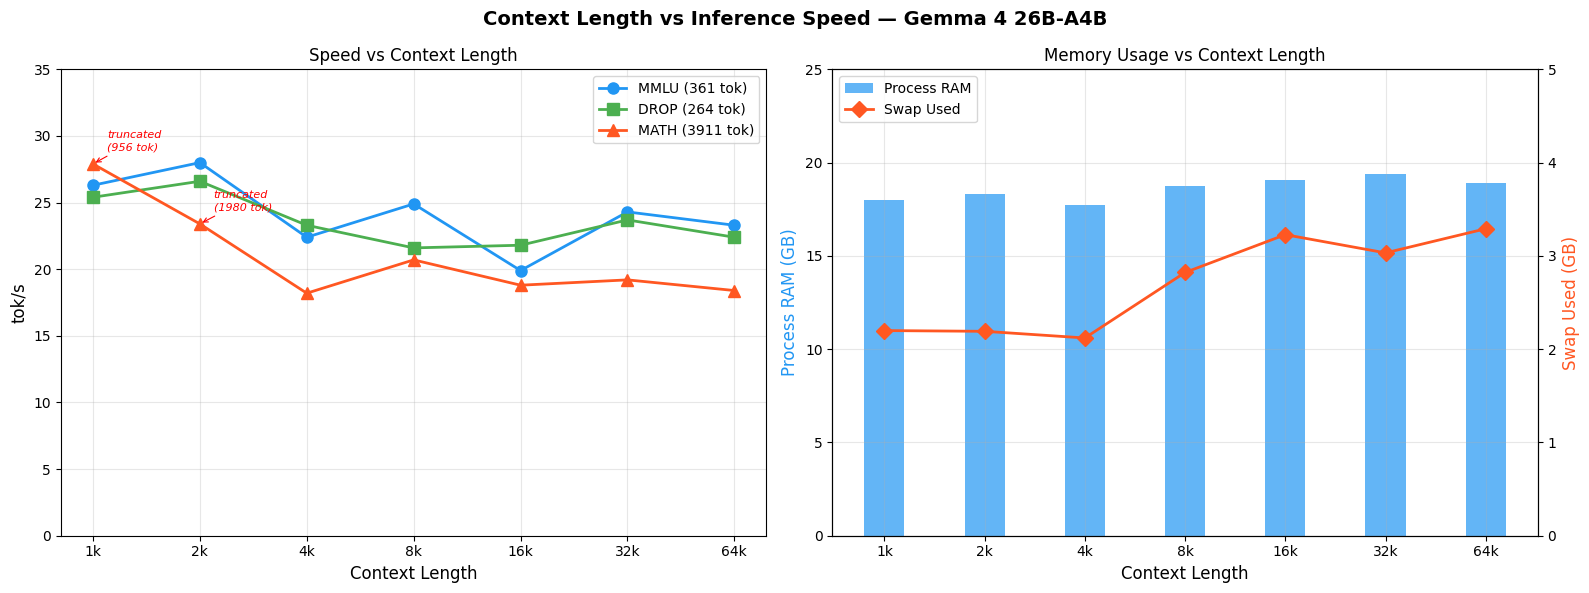

In [18]:
### 12a. tok/s vs Context Length
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Context Length vs Inference Speed — Gemma 4 26B-A4B', fontsize=14, fontweight='bold')

ctx_sizes = ctx_df['context_length'].values
x_labels = [f'{c//1024}k' if c >= 1024 else str(c) for c in ctx_sizes]

# Left: tok/s for each question type
ax1.plot(range(len(ctx_sizes)), ctx_df['MMLU (short)_tok_s'], 'o-', color='#2196F3', linewidth=2, markersize=8, label='MMLU (361 tok)')
ax1.plot(range(len(ctx_sizes)), ctx_df['DROP (medium)_tok_s'], 's-', color='#4CAF50', linewidth=2, markersize=8, label='DROP (264 tok)')
ax1.plot(range(len(ctx_sizes)), ctx_df['MATH (thinking)_tok_s'], '^-', color='#FF5722', linewidth=2, markersize=8, label='MATH (3911 tok)')
ax1.set_xticks(range(len(ctx_sizes)))
ax1.set_xticklabels(x_labels)
ax1.set_xlabel('Context Length', fontsize=12)
ax1.set_ylabel('tok/s', fontsize=12)
ax1.set_title('Speed vs Context Length', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 35)

# Annotate truncated MATH results
for i, (ctx, tok) in enumerate(zip(ctx_sizes, ctx_df['MATH (thinking)_comp_tok'])):
    if tok < 3911:
        ax1.annotate(f'truncated\n({tok} tok)', 
                    (i, ctx_df['MATH (thinking)_tok_s'].iloc[i]),
                    textcoords='offset points', xytext=(10, 10),
                    fontsize=8, color='red', fontstyle='italic',
                    arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

# Right: RAM and Swap
ax2_swap = ax2.twinx()
bars = ax2.bar(range(len(ctx_sizes)), ctx_df['ram_mb'] / 1024, width=0.4, color='#2196F3', alpha=0.7, label='Process RAM')
ax2_swap.plot(range(len(ctx_sizes)), ctx_df['swap_mb'] / 1024, 'D-', color='#FF5722', linewidth=2, markersize=8, label='Swap Used')
ax2.set_xticks(range(len(ctx_sizes)))
ax2.set_xticklabels(x_labels)
ax2.set_xlabel('Context Length', fontsize=12)
ax2.set_ylabel('Process RAM (GB)', fontsize=12, color='#2196F3')
ax2_swap.set_ylabel('Swap Used (GB)', fontsize=12, color='#FF5722')
ax2.set_title('Memory Usage vs Context Length', fontsize=12)
ax2.set_ylim(0, 25)
ax2_swap.set_ylim(0, 5)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_swap.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chart_context_vs_speed.png', dpi=150, bbox_inches='tight')
plt.show()

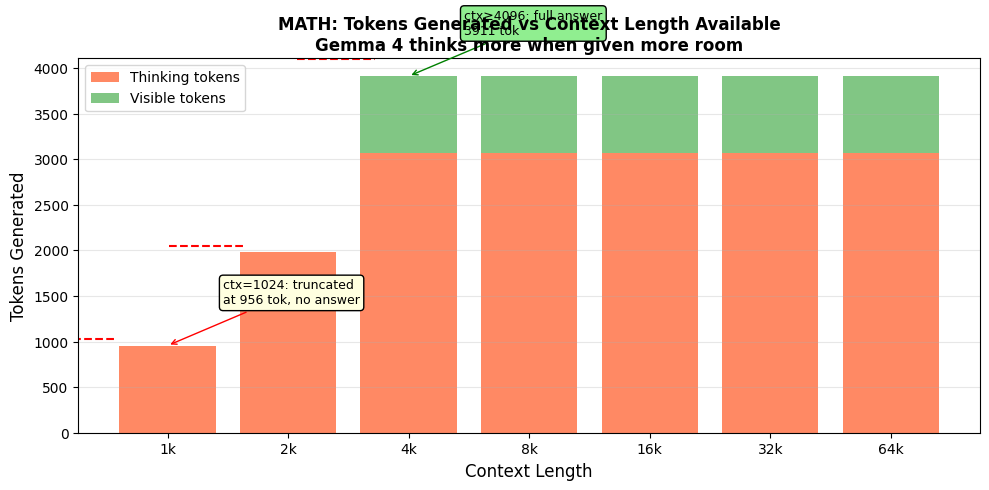

In [19]:
### 12b. MATH token count vs context — the model uses what you give it
fig, ax = plt.subplots(figsize=(10, 5))

math_tok = ctx_df['MATH (thinking)_comp_tok'].values
math_think = ctx_df['MATH (thinking)_think_tok'].values
math_vis = ctx_df['MATH (thinking)_vis_tok'].values

ax.bar(range(len(ctx_sizes)), math_think, color='#FF5722', alpha=0.7, label='Thinking tokens')
ax.bar(range(len(ctx_sizes)), math_vis, bottom=math_think, color='#4CAF50', alpha=0.7, label='Visible tokens')

# Add context limit line
for i, ctx in enumerate(ctx_sizes):
    if math_tok[i] >= ctx * 0.9:  # close to limit
        ax.axhline(y=ctx, xmin=(i-0.3)/len(ctx_sizes), xmax=(i+0.3)/len(ctx_sizes), 
                   color='red', linestyle='--', linewidth=1.5)

ax.set_xticks(range(len(ctx_sizes)))
ax.set_xticklabels(x_labels)
ax.set_xlabel('Context Length', fontsize=12)
ax.set_ylabel('Tokens Generated', fontsize=12)
ax.set_title('MATH: Tokens Generated vs Context Length Available\nGemma 4 thinks more when given more room', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

# Annotate key observations
ax.annotate(f'ctx=1024: truncated\nat {math_tok[0]} tok, no answer', 
           (0, math_tok[0]), textcoords='offset points', xytext=(40, 30),
           fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
           bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

ax.annotate(f'ctx≥4096: full answer\n{math_tok[2]} tok', 
           (2, math_tok[2]), textcoords='offset points', xytext=(40, 30),
           fontsize=9, arrowprops=dict(arrowstyle='->', color='green'),
           bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen'))

plt.tight_layout()
plt.savefig('chart_context_vs_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

### Findings

1. **Context length does not meaningfully affect tok/s.** MMLU and DROP speeds fluctuate ±4 tok/s across all settings with no clear trend — noise exceeds signal.

2. **RAM grows modestly** (~1.4GB from 1k to 65k context). Swap grows more (~1.1GB), suggesting KV cache spills to disk at larger settings.

3. **The model needs ≥4096 context** for this MATH question. At 1024 and 2048, it was truncated and returned an empty answer.

4. **At ctx=2048, the model generated 1980 tokens of thinking** (nearly the full budget) vs 956 at ctx=1024 — it used whatever room was available.

**Recommendation:** Use context_length=8192 or 16384 for benchmarking. Enough room for all tasks, minimal memory penalty.

## 13. Tokens/Second Distribution

Total benchmark time is driven by two factors: **how fast each token is generated (tok/s)** and **how many tokens are generated per question**. The overall time ratio (Qwen3-Coder is 10x faster than Gemma 4) comes mostly from the second factor — Qwen3-Coder doesn't think, so it generates way fewer tokens. But what about raw generation speed?

Data filtering: removed 30 outliers (tok/s > 50) which are artifacts of 1-second timestamp precision in old log data. The new bench2.py data (all MATH + Gemma GPQA) uses high-precision Python time.time().

In [20]:
# Filter combined timing data for tok/s analysis
speed_df = tdf[(tdf['actual_tok_s'] > 0) & (tdf['actual_tok_s'] <= 50)].copy()
print(f'Total entries after filtering: {len(speed_df)}')

# Overall stats per model
stats = speed_df.groupby('model_short')['actual_tok_s'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
stats.columns = ['N', 'Mean', 'Median', 'Std', 'Min', 'Max']
print('\n=== Overall tok/s per model ===')
print(stats.round(1).to_string())

Total entries after filtering: 2044

=== Overall tok/s per model ===
               N  Mean  Median   Std  Min   Max
model_short                                    
Gemma4       704  15.3    15.7   5.2  0.0  46.4
Qwen3-Coder  684  14.0    15.6  10.2  0.0  35.6
huihui-ref   656  18.2    18.4   6.1  0.3  49.1


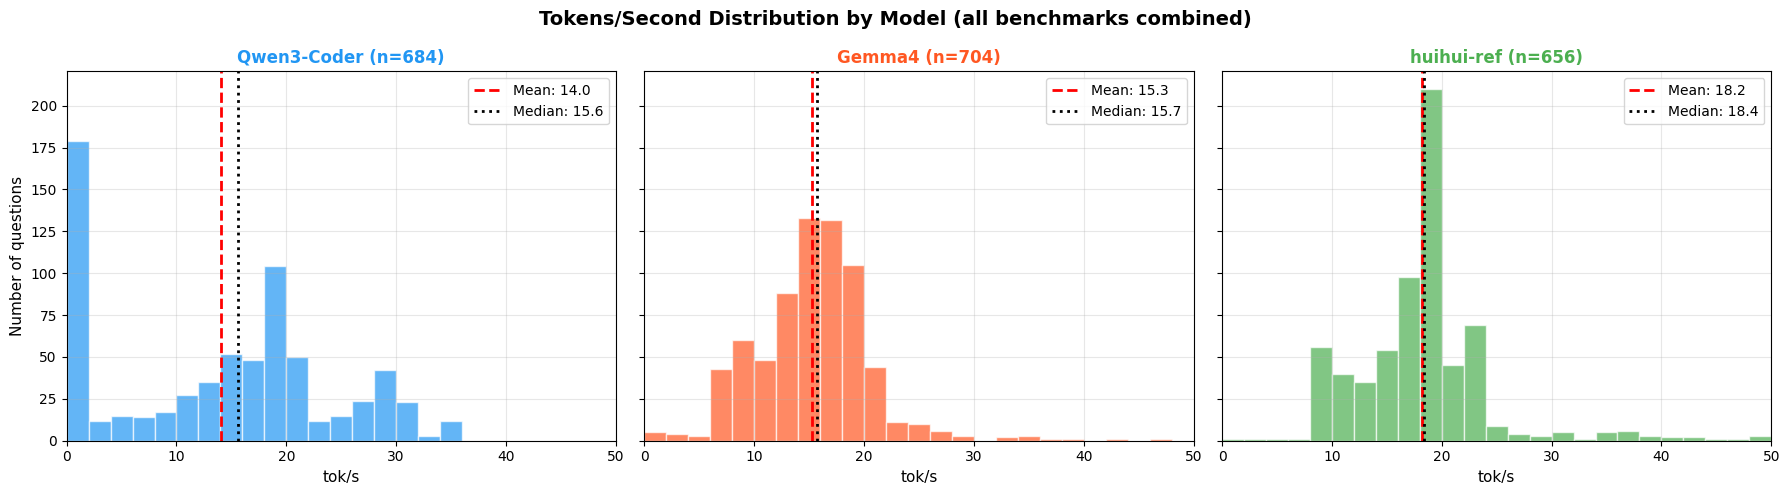

In [21]:
### 13a. Histogram of tok/s per model (all benchmarks combined)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Tokens/Second Distribution by Model (all benchmarks combined)', fontsize=14, fontweight='bold')

bins = np.linspace(0, 50, 26)

for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    speeds = speed_df[speed_df['model_short'] == model]['actual_tok_s'].values
    
    ax.hist(speeds, bins=bins, color=COLORS[model], alpha=0.7, edgecolor='white')
    
    mean = np.mean(speeds)
    median = np.median(speeds)
    
    ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.1f}')
    ax.axvline(median, color='black', linestyle=':', linewidth=2, label=f'Median: {median:.1f}')
    
    ax.set_title(f'{model} (n={len(speeds)})', fontsize=12, fontweight='bold', color=COLORS[model])
    ax.set_xlabel('tok/s', fontsize=11)
    if i == 0:
        ax.set_ylabel('Number of questions', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 50)

plt.tight_layout()
plt.savefig('chart_tok_s_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

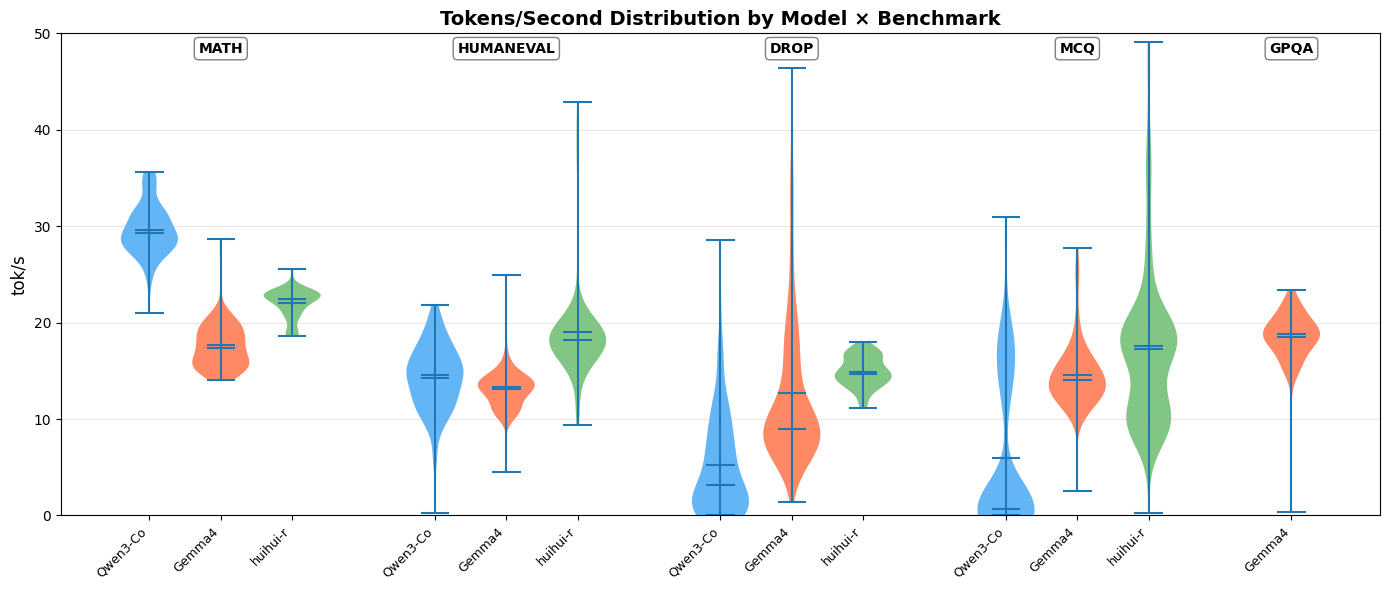

In [22]:
### 13b. Tok/s per benchmark, per model (violin plots)
# Only use new bench2.py data for apples-to-apples comparison (avoids log-timestamp precision issues)
new_data = speed_df[speed_df.get('source', '') == 'bench2'] if 'source' in speed_df.columns else speed_df

fig, ax = plt.subplots(figsize=(14, 6))

# Build data by (model, bench) pairs, focused on benchmarks where we have clean data
bench_list = ['math', 'humaneval', 'drop', 'mcq', 'gpqa']
positions = []
all_data = []
labels = []
face_colors = []
pos = 0
for bench in bench_list:
    for model in MODEL_ORDER:
        speeds = speed_df[(speed_df['model_short'] == model) & (speed_df['bench'] == bench)]['actual_tok_s'].values
        if len(speeds) >= 5:
            positions.append(pos)
            all_data.append(speeds)
            labels.append(f'{model[:8]}')
            face_colors.append(COLORS[model])
            pos += 1
    pos += 1  # gap between benchmarks

parts = ax.violinplot(all_data, positions=positions, widths=0.8, showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], face_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('tok/s', fontsize=12)
ax.set_title('Tokens/Second Distribution by Model × Benchmark', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 50)

# Add benchmark group labels
bench_label_positions = {}
current_bench = None
start_pos = 0
for i, bench in enumerate(bench_list):
    # Find positions for this bench
    bench_positions = [p for p, l in zip(positions, labels)]
# Simpler: add text labels at the top
xticks_by_bench = {}
idx = 0
cur_pos = 0
for bench in bench_list:
    start = cur_pos
    count = 0
    for model in MODEL_ORDER:
        speeds = speed_df[(speed_df['model_short'] == model) & (speed_df['bench'] == bench)]['actual_tok_s'].values
        if len(speeds) >= 5:
            count += 1
            cur_pos += 1
    if count > 0:
        mid = start + (count - 1) / 2
        ax.text(mid, 48, bench.upper(), ha='center', fontsize=10, fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
    cur_pos += 1  # gap

plt.tight_layout()
plt.savefig('chart_tok_s_by_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

### Findings

**Overall medians (all benchmarks combined):**
- Qwen3-Coder: ~15.6 tok/s
- Gemma 4: ~15.7 tok/s  
- huihui-ref: ~18.4 tok/s

**Surprising result:** huihui-ref has the **highest raw generation speed** despite being the smallest model (Q3_K_S, 14GB). This makes sense: smaller quantization = faster memory reads per token.

**Qwen3-Coder's 10x speed advantage in total time does NOT come from higher tok/s** — it comes from generating far fewer tokens per question (no thinking). Raw generation rate is actually similar to Gemma 4 and slower than huihui-ref.

**MATH tok/s (from new bench2.py data, apples-to-apples):**
- Qwen3-Coder: 29.2 (no thinking, short output, smaller context)
- Gemma 4: 17.4 (heavy thinking, large context)
- huihui-ref: 22.5

**The implication:** if we could run Gemma 4 with thinking OFF (using its reasoning toggle), it would likely generate at similar raw tok/s but with 5-10x fewer tokens per question. That could be the "best of both worlds" configuration we speculated about.